# Industrial Predictive Maintenance - Model Optimization & Explainability

This notebook focuses on improving machine failure prediction performance using imbalance-aware modeling, threshold optimization, and explainable AI techniques.

Key objectives:
- Handle severe class imbalance
- Optimize machine failure detection
- Improve operational recall while maintaining precision
- Tune Random Forest performance
- Interpret model behavior using feature importance and SHAP

In [1]:
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV 

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

## Data and Artifact Loading

Previously saved datasets, preprocessing artifacts, and baseline models are loaded to ensure reproducibility and avoid unnecessary recomputation after kernel restarts.

In [2]:
# -------------------------------
# Load datasets
# -------------------------------

# Full feature datasets
train_full_df = pd.read_csv(
    "../data/full_feature_dataset.csv"
)

test_full_df = pd.read_csv(
    "../data/full_feature_test_dataset.csv"
)


# Reduced feature datasets
train_reduced_df = pd.read_csv(
    "../data/reduced_feature_dataset.csv"
)

test_reduced_df = pd.read_csv(
    "../data/reduced_feature_test_dataset.csv"
)


# -------------------------------
# Train-test splits
# -------------------------------

# Full feature split
X_train_full = train_full_df.drop(
    'Machine failure',
    axis=1
)

y_train_full = train_full_df[
    'Machine failure'
]


X_test_full = test_full_df.drop(
    'Machine failure',
    axis=1
)

y_test_full = test_full_df[
    'Machine failure'
]


# Reduced feature split
X_train_reduced = train_reduced_df.drop(
    'Machine failure',
    axis=1
)

y_train_reduced = train_reduced_df[
    'Machine failure'
]


X_test_reduced = test_reduced_df.drop(
    'Machine failure',
    axis=1
)

y_test_reduced = test_reduced_df[
    'Machine failure'
]


# -------------------------------
# Load scaler
# -------------------------------

with open("../models/scaler.pkl", "rb") as file:
    scaler = pickle.load(file)


# -------------------------------
# Recreate scaled datasets
# -------------------------------

X_train_reduced_scaled = scaler.transform(
    X_train_reduced
)

X_test_reduced_scaled = scaler.transform(
    X_test_reduced
)


# -------------------------------
# Load baseline models
# -------------------------------

with open("../models/logistic_regression.pkl", "rb") as file:
    baseline_lr = pickle.load(file)


with open("../models/decision_tree.pkl", "rb") as file:
    baseline_dt = pickle.load(file)


with open("../models/random_forest.pkl", "rb") as file:
    baseline_rf = pickle.load(file)

# Load baseline models
with open("../models/logistic_regression.pkl", "rb") as file:
    baseline_lr = pickle.load(file)


with open("../models/decision_tree.pkl", "rb") as file:
    baseline_dt = pickle.load(file)


with open("../models/random_forest.pkl", "rb") as file:
    baseline_rf = pickle.load(file)

In [3]:
# Load scaler
with open("../models/scaler.pkl", "rb") as file:
    scaler = pickle.load(file)

# Recreate scaled datasets
X_train_reduced_scaled = scaler.transform(
    X_train_reduced
)

X_test_reduced_scaled = scaler.transform(
    X_test_reduced
)

## Class Imbalance Analysis

Industrial machine failures are rare operational events, resulting in a heavily imbalanced dataset. Such imbalance can bias models toward predicting the majority healthy class.

This section evaluates:
- failure distribution
- imbalance severity
- implications for predictive maintenance systems

In [4]:
# Training class distribution
failure_distribution = y_train_full.value_counts()

failure_percentage = (
    y_train_full.value_counts(normalize=True) * 100
).round(2)

imbalance_df = pd.DataFrame({
    'Class': failure_distribution.index,
    'Count': failure_distribution.values,
    'Percentage': failure_percentage.values
})

imbalance_df

,Class,Count,Percentage
0,0,7246,96.61
1,1,254,3.39


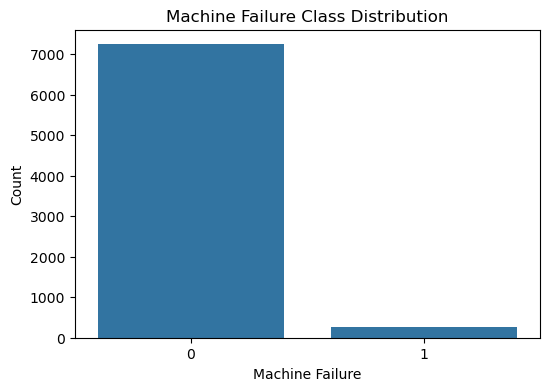

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=y_train_full
)

plt.title('Machine Failure Class Distribution')

plt.xlabel('Machine Failure')

plt.ylabel('Count')

plt.show()

In [6]:
# Failure to non-failure ratio
normal_count = failure_distribution[0]

failure_count = failure_distribution[1]

print(f"Normal Samples  : {normal_count}")

print(f"Failure Samples : {failure_count}")

print(f"Ratio           : 1 : {round(normal_count/failure_count,2)}")

Normal Samples  : 7246
Failure Samples : 254
Ratio           : 1 : 28.53


## Imbalance-Aware Modeling

To improve minority failure detection, multiple imbalance handling strategies were evaluated:
- class weighting
- synthetic oversampling (SMOTE)

These approaches are compared against baseline models to assess their operational effectiveness.

In [7]:
# Weighted Logistic Regression
weighted_lr = LogisticRegression(
    class_weight='balanced',
    random_state=0,
    max_iter=1000
)

weighted_lr.fit(
    X_train_reduced_scaled,
    y_train_reduced
)

# Weighted Decision Tree
weighted_dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=0
)

weighted_dt.fit(
    X_train_full,
    y_train_full
)

# Weighted Random Forest
weighted_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=0,
    n_estimators=100
)

weighted_rf.fit(
    X_train_full,
    y_train_full
)

RandomForestClassifier(class_weight='balanced', random_state=0)

In [8]:
# Baseline predictions
y_pred_lr_baseline = baseline_lr.predict(
    X_test_reduced_scaled
)

y_pred_dt_baseline = baseline_dt.predict(
    X_test_full
)

y_pred_rf_baseline = baseline_rf.predict(
    X_test_full
)


# Weighted predictions
y_pred_lr_weighted = weighted_lr.predict(
    X_test_reduced_scaled
)

y_pred_dt_weighted = weighted_dt.predict(
    X_test_full
)

y_pred_rf_weighted = weighted_rf.predict(
    X_test_full
)

In [9]:
comparison_results = pd.DataFrame({

    'Approach': [
        'Baseline',
        'Baseline',
        'Baseline',
        'Class Weighted',
        'Class Weighted',
        'Class Weighted'
    ],

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Precision': [

        precision_score(
            y_test_reduced,
            y_pred_lr_baseline
        ),

        precision_score(
            y_test_full,
            y_pred_dt_baseline
        ),

        precision_score(
            y_test_full,
            y_pred_rf_baseline
        ),

        precision_score(
            y_test_reduced,
            y_pred_lr_weighted
        ),

        precision_score(
            y_test_full,
            y_pred_dt_weighted
        ),

        precision_score(
            y_test_full,
            y_pred_rf_weighted
        )
    ],

    'Recall': [

        recall_score(
            y_test_reduced,
            y_pred_lr_baseline
        ),

        recall_score(
            y_test_full,
            y_pred_dt_baseline
        ),

        recall_score(
            y_test_full,
            y_pred_rf_baseline
        ),

        recall_score(
            y_test_reduced,
            y_pred_lr_weighted
        ),

        recall_score(
            y_test_full,
            y_pred_dt_weighted
        ),

        recall_score(
            y_test_full,
            y_pred_rf_weighted
        )
    ],

    'F1 Score': [

        f1_score(
            y_test_reduced,
            y_pred_lr_baseline
        ),

        f1_score(
            y_test_full,
            y_pred_dt_baseline
        ),

        f1_score(
            y_test_full,
            y_pred_rf_baseline
        ),

        f1_score(
            y_test_reduced,
            y_pred_lr_weighted
        ),

        f1_score(
            y_test_full,
            y_pred_dt_weighted
        ),

        f1_score(
            y_test_full,
            y_pred_rf_weighted
        )
    ],

    'ROC-AUC': [

        roc_auc_score(
            y_test_reduced,
            baseline_lr.predict_proba(
                X_test_reduced_scaled
            )[:,1]
        ),

        roc_auc_score(
            y_test_full,
            baseline_dt.predict_proba(
                X_test_full
            )[:,1]
        ),

        roc_auc_score(
            y_test_full,
            baseline_rf.predict_proba(
                X_test_full
            )[:,1]
        ),

        roc_auc_score(
            y_test_reduced,
            weighted_lr.predict_proba(
                X_test_reduced_scaled
            )[:,1]
        ),

        roc_auc_score(
            y_test_full,
            weighted_dt.predict_proba(
                X_test_full
            )[:,1]
        ),

        roc_auc_score(
            y_test_full,
            weighted_rf.predict_proba(
                X_test_full
            )[:,1]
        )
    ]
})

comparison_results.round(3)

,Approach,Model,Precision,Recall,F1 Score,ROC-AUC
0,Baseline,Logistic Regression,1.000,0.035,0.068,0.798
1,Baseline,Decision Tree,0.774,0.765,0.769,0.878
2,Baseline,Random Forest,0.937,0.694,0.797,0.952
3,Class Weighted,Logistic Regression,0.094,0.765,0.168,0.799
4,Class Weighted,Decision Tree,0.756,0.729,0.743,0.861
5,Class Weighted,Random Forest,0.967,0.682,0.800,0.957


### Initial Model Comparison Insights

Random Forest models significantly outperformed Logistic Regression and Decision Tree models across precision, recall, F1-score, and ROC-AUC metrics.

Key observations:
- Logistic Regression struggled to capture nonlinear industrial failure behavior
- Decision Trees showed unstable performance under imbalance handling
- Random Forest consistently produced the strongest operational balance

Class weighting improved minority detection slightly, but gains were limited compared to threshold optimization performed later.

### SMOTE Oversampling Experiment

SMOTE-based synthetic oversampling was experimentally evaluated to improve minority machine failure detection.

Although SMOTE improved recall, it also introduced a significant increase in false positives and reduced precision, making the model less operationally reliable for predictive maintenance deployment.

As a result, SMOTE was not included in the final production pipeline.

## Threshold Optimization

Default classification thresholds may not be optimal for predictive maintenance systems where minimizing unexpected failures is critical.

Instead of relying solely on the default probability threshold of 0.5, threshold tuning was performed to optimize the operational balance between:
- precision
- recall
- false alarms
- missed failures

This stage evaluates how decision thresholds influence model behavior across multiple classifiers.

In [11]:
# Probability scores for all models
model_probabilities = {

    # Baseline Models
    'Baseline LR': baseline_lr.predict_proba(
        X_test_reduced_scaled
    )[:,1],

    'Baseline DT': baseline_dt.predict_proba(
        X_test_full
    )[:,1],

    'Baseline RF': baseline_rf.predict_proba(
        X_test_full
    )[:,1],


    # Weighted Models
    'Weighted LR': weighted_lr.predict_proba(
        X_test_reduced_scaled
    )[:,1],

    'Weighted DT': weighted_dt.predict_proba(
        X_test_full
    )[:,1],

    'Weighted RF': weighted_rf.predict_proba(
        X_test_full
    )[:,1]
}
# Thresholds to test
thresholds = [
    0.5,
    0.45,
    0.4,
    0.35,
    0.3,
]


# Store results
threshold_results = []


for model_name, probs in model_probabilities.items():

    for threshold in thresholds:

        y_pred = (
            probs >= threshold
        ).astype(int)

        
        # Reduced dataset models
        if 'LR' in model_name:

            y_true = y_test_reduced

        # Full dataset models
        else:

            y_true = y_test_full


        precision = precision_score(
            y_true,
            y_pred
        )

        recall = recall_score(
            y_true,
            y_pred
        )

        f1 = f1_score(
            y_true,
            y_pred
        )

        
        cm = confusion_matrix(
            y_true,
            y_pred
        )

        tn, fp, fn, tp = cm.ravel()


        threshold_results.append({

            'Model': model_name,

            'Threshold': threshold,

            'Precision': round(precision,3),

            'Recall': round(recall,3),

            'F1 Score': round(f1,3),

            'False Positives': fp,

            'False Negatives': fn
        })


threshold_results_df = pd.DataFrame(
    threshold_results
)

threshold_results_df

,Model,Threshold,Precision,Recall,F1 Score,False Positives,False Negatives
0,Baseline LR,0.50,1.000,0.035,0.068,0,82
1,Baseline LR,0.45,1.000,0.071,0.132,0,79
2,Baseline LR,0.40,0.900,0.106,0.189,1,76
3,Baseline LR,0.35,0.917,0.129,0.227,1,74
4,Baseline LR,0.30,0.810,0.200,0.321,4,68
5,Baseline DT,0.50,0.774,0.765,0.769,19,20
6,Baseline DT,0.45,0.774,0.765,0.769,19,20
7,Baseline DT,0.40,0.774,0.765,0.769,19,20
8,Baseline DT,0.35,0.774,0.765,0.769,19,20
9,Baseline DT,0.30,0.774,0.765,0.769,19,20


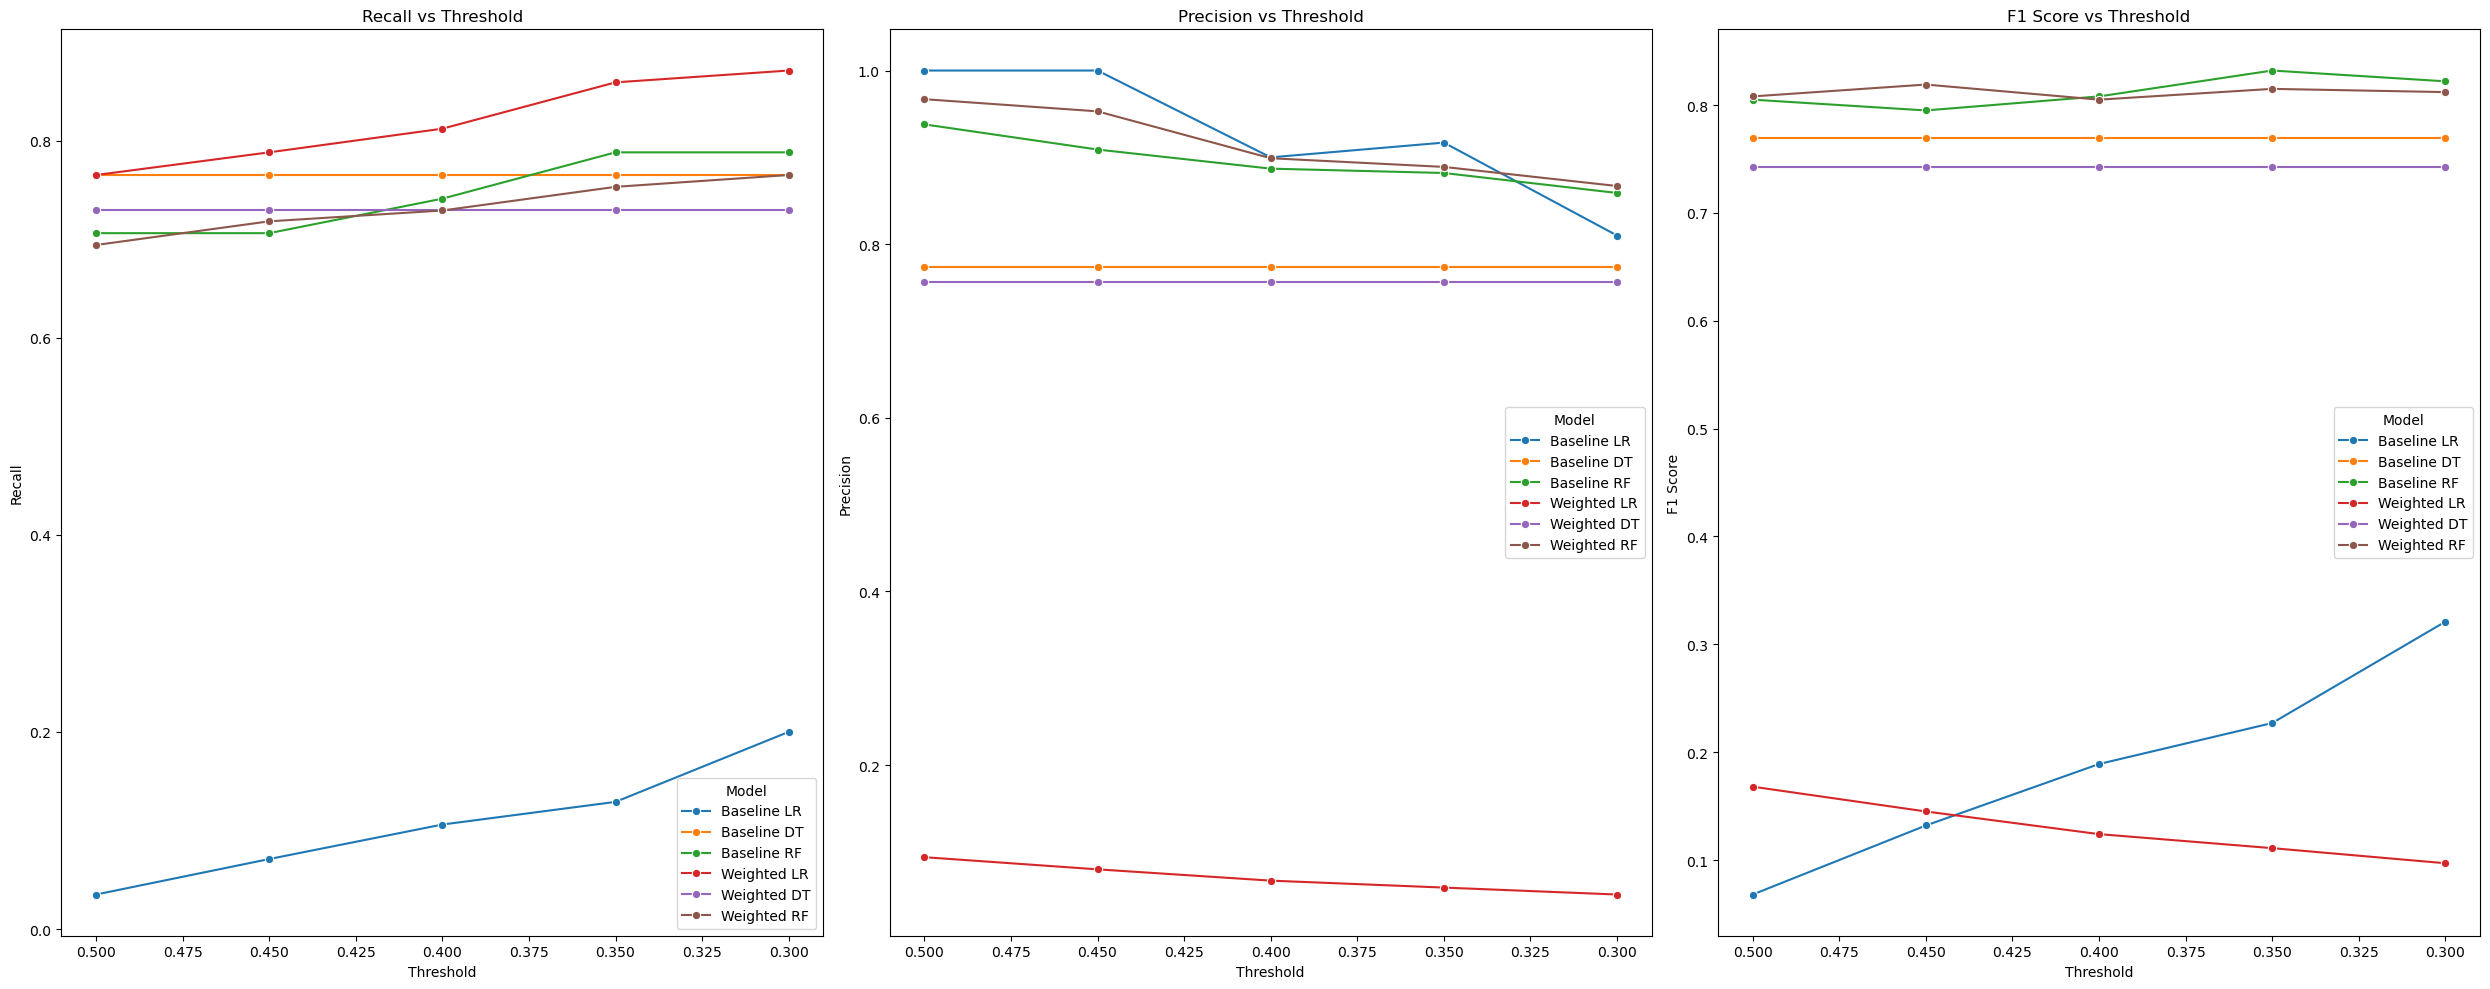

In [12]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(25,10)
)


# Recall
sns.lineplot(
    data=threshold_results_df,
    x='Threshold',
    y='Recall',
    hue='Model',
    marker='o',
    ax=axes[0]
)

axes[0].invert_xaxis()

axes[0].set_title('Recall vs Threshold')


# Precision
sns.lineplot(
    data=threshold_results_df,
    x='Threshold',
    y='Precision',
    hue='Model',
    marker='o',
    ax=axes[1]
)

axes[1].invert_xaxis()

axes[1].set_title('Precision vs Threshold')


# F1
sns.lineplot(
    data=threshold_results_df,
    x='Threshold',
    y='F1 Score',
    hue='Model',
    marker='o',
    ax=axes[2]
)

axes[2].invert_xaxis()

axes[2].set_title('F1 Score vs Threshold')


plt.tight_layout()

plt.show()

### Threshold Optimization Insights

Threshold optimization produced more meaningful improvements than imbalance handling techniques such as class weighting or SMOTE.

Key findings:
- Lowering classification thresholds improved machine failure recall
- Random Forest adapted best to threshold tuning while maintaining strong precision
- Baseline Random Forest at lower thresholds outperformed weighted and SMOTE-based variants

This demonstrated that operational decision policy tuning was more effective than synthetic oversampling for this predictive maintenance problem.

## Random Forest Hyperparameter Optimization

After threshold-based evaluation, Random Forest emerged as the strongest performing model family.

GridSearchCV was used to optimize:
- tree depth
- number of estimators
- feature sampling strategy
- node splitting behavior

ROC-AUC was selected as the optimization metric because it evaluates ranking quality independent of classification threshold.

In [13]:
param_grid = {

    'n_estimators': [
        100,
        200,
        300
    ],

    'max_depth': [
        None,
        10,
        20,
        30
    ],

    'min_samples_split': [
        2,
        5,
        10
    ],

    'min_samples_leaf': [
        1,
        2,
        4
    ],

    'max_features': [
        'sqrt',
        'log2'
    ]
}

In [14]:
grid_rf = GridSearchCV(

    estimator=RandomForestClassifier(
        random_state=0
    ),

    param_grid=param_grid,

    scoring='roc_auc',

    cv=5,

    n_jobs=-1,

    verbose=2
)

In [15]:
grid_rf.fit(
    X_train_full,
    y_train_full
)
best_rf = grid_rf.best_estimator_

print(grid_rf.best_params_)

print(grid_rf.best_score_)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
{'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
0.9835733362450426


In [ ]:
best_rf_probs = best_rf.predict_proba(
    X_test_full
)[:,1]
thresholds = [
    0.5,
    0.45,
    0.4,
    0.35,
    0.3,
    0.25,
    0.2,
]

tuned_threshold_results = []


for threshold in thresholds:

    y_pred = (
        best_rf_probs >= threshold
    ).astype(int)

    
    precision = precision_score(
        y_test_full,
        y_pred
    )

    recall = recall_score(
        y_test_full,
        y_pred
    )

    f1 = f1_score(
        y_test_full,
        y_pred
    )

    
    cm = confusion_matrix(
        y_test_full,
        y_pred
    )

    tn, fp, fn, tp = cm.ravel()


    tuned_threshold_results.append({

        'Threshold': threshold,

        'Precision': round(precision,3),

        'Recall': round(recall,3),

        'F1 Score': round(f1,3),

        'False Positives': fp,

        'False Negatives': fn
    })


tuned_threshold_results_df = pd.DataFrame(
    tuned_threshold_results
)

tuned_threshold_results_df


### Hyperparameter Tuning Insights

Hyperparameter tuning improved the probability ranking capability of the Random Forest model and produced a better operational balance after threshold optimization.

Best configuration:
- max_depth = 10
- max_features = log2
- n_estimators = 200
- threshold = 0.40

Final tuned configuration achieved:
- Precision = 0.904
- Recall = 0.776
- F1 Score = 0.835

This configuration reduced unexpected machine failures while maintaining low false alarm rates.

## Feature Importance Analysis

Feature importance analysis was performed to identify the operational variables contributing most significantly to machine failure prediction.

This helps interpret:
- mechanical load conditions
- thermal behavior
- operational wear patterns

and validates the effectiveness of engineered industrial features.

In [ ]:
feature_importance = pd.DataFrame({

    'Feature': X_train_full.columns,

    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Tuned Random Forest Feature Importance')

plt.show()

### Feature Importance Insights

Engineered industrial features contributed significantly to model performance.

Key observations:
- Estimated Power emerged as the most important operational feature
- Rotational Speed and Torque strongly influenced machine failure prediction
- Temperature Difference captured meaningful thermal behavior better than raw temperature variables

The dominance of engineered features validated the effectiveness of domain-informed feature engineering for predictive maintenance systems.

## SHAP Explainability

SHAP was used to interpret how operational variables influence machine failure predictions.

The SHAP summary plot helps explain:
- which features most strongly affect predictions
- whether high or low feature values increase failure risk
- overall model decision behavior

This improves interpretability of the predictive maintenance system and reduces black-box model behavior.

In [ ]:
explainer = shap.TreeExplainer(
    best_rf
)

X_shap_sample = X_test_full.sample(
    500,
    random_state=0
)
shap_values = explainer.shap_values(
    X_shap_sample
)
shap.summary_plot(
    shap_values[:,:,1],
    X_shap_sample
)

In [ ]:
shap.summary_plot(
    shap_values[:,:,1],
    X_shap_sample,
    plot_type='bar'
)

## Final Conclusions

The final predictive maintenance pipeline combined:
- Tuned Random Forest architecture
- Threshold optimization
- Domain-informed feature engineering

Key findings:
- Threshold tuning improved operational performance more effectively than SMOTE or class weighting
- Random Forest consistently outperformed Logistic Regression and Decision Tree models
- Engineered operational features significantly improved predictive capability
- The final model achieved strong precision-recall balance suitable for industrial maintenance environments

Final selected configuration:
- Tuned Random Forest
- Threshold = 0.40
- Precision = 0.904
- Recall = 0.776
- F1 Score = 0.835

Note:
The final predictive maintenance system uses the tuned Random Forest model with a custom operational threshold of 0.40 for machine failure classification.

In [ ]:
# Final threshold configuration
final_threshold = 0.40


# Final predictions
final_probs = best_rf.predict_proba(
    X_test_full
)[:,1]

final_predictions = (
    final_probs >= final_threshold
).astype(int)


# Save feature importance report
feature_importance.to_csv(
    "../reports/feature_importance.csv",
    index=False
)


# Save final tuned Random Forest model
with open("../models/final_tuned_rf.pkl", "wb") as file:
    pickle.dump(best_rf, file)


# Save best hyperparameters
best_rf_params = grid_rf.best_params_

with open("../models/final_rf_best_params.pkl", "wb") as file:
    pickle.dump(best_rf_params, file)


# Save final operational threshold
with open("../models/final_rf_threshold.pkl", "wb") as file:
    pickle.dump(final_threshold, file)


print(best_rf_params)
print("Final model artifacts saved successfully.")

In [1]:
dashboard_df = X_test_full.copy()

dashboard_df['Actual Failure'] = y_test_full.values

dashboard_df['Predicted Failure'] = final_predictions

dashboard_df['Failure Probability'] = final_probs

NameError: name 'X_test_full' is not defined